In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_DeepLearning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_DeepLearning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_DeepLearning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_DeepLearning/9
    print("準備完了！このまま下のセルを実行できます。")

# 第9章 正則化 (Regularization)
## 9.5 残差結合 (Residual Connections)

本ノートブックは、Christopher M. Bishop & Hugh Bishop (2024)『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』第9章「正則化」第9.5節「残差結合 (Residual Connections)」の理論的背景、数学的導出、再利用可能な共通モジュール実装、および可視化プロットを提供します。

---

### 目次
1. **9.5 超深層ネットワークの退化問題と残差学習の動機**
   - 勾配消失・爆発を超えた「勾配破砕（Shattered Gradients）」現象 (Balduzzi et al., 2017)
   - 図 9.12: 層の深さと入力勾配の空間自己相関（ホワイトノイズ vs ブラウン運動）
2. **残差ブロックの数学的定式化**
   - 基本残差写像と恒等写像スキップ接続 (式 9.32 - 9.37)
   - チャネル次元不一致と射影行列 $\mathbf{W}$ (式 9.41)
   - 図 9.13: 3ブロック残差ネットワークのアーキテクチャ
3. **幾何学的最適化と損失曲面の平滑化 (Loss Landscape Smoothing)**
   - フィルタ正規化（Filter Normalization）による損失曲面可視化 (Li et al., 2017)
   - 図 9.14: スキップ結合なし（混沌・多峰） vs スキップ結合あり（滑らかな凸状ボウル）の3D比較
4. **アンサンブルとしての残差ネットワーク解釈 (Veit et al., 2016)**
   - 再帰的展開による $2^L$ 個の並列パス表現 (式 9.38 - 9.40 / 演習 9.13)
   - 二項分布に従う有効パス長とブロック除去（Lesion Study）に対する頑健性
   - 図 9.15: 展開形式によるパスアンサンブルの可視化
5. **アーキテクチャの変種: 事後活性化 vs 事前活性化 (He et al., 2016b)**
   - Post-activation と Pre-activation の違い
   - 勾配ハイウェイ（Gradient Highway）の完全性担保
   - 図 9.16: Post-activation と Pre-activation の構造比較（教科書の誤植に関する注記を含む）
6. **数値検証と共通モジュールの動作確認**
   - 解析的ヤコビアンの連続性検証
   - 事後・事前活性化ブロックおよび射影スキップの順伝播・逆伝播検証
7. **まとめと第9.6節（モデル平均とドロップアウト）への展望**


## 1. 超深層ネットワークの退化問題と勾配破砕現象 (Shattered Gradients)

従来のフィードフォワード・ニューラルネットワークにおいて、層数を数十層から100層以上に深く積み重ねると、**訓練誤差自体が増大して最適化が極めて困難になる「退化問題（Degradation Problem）」**が生じます（He et al., 2016a）。これは単純な過剰適合（Overfitting）ではなく、**最適化の難易度（Optimization Difficulty）**に起因します。

### 勾配消失・爆発を超えた本質的課題: 勾配破砕 (Balduzzi et al., 2017)
バッチ正規化（Batch Normalization: 第8章）や適切な重み初期化（He初期化等）を用いても、標準的なReLUフィードフォワードネットワークでは層が深くなるにつれて、入力 $\mathbf{x}$ に対する出力 $y$ の勾配 $\nabla_{\mathbf{x}} y$ が微小な入力変化に対して符号を激しく反転させるようになります。

- **浅いネットワーク（2層）**:
  勾配 $\frac{\partial y}{\partial x}$ は入力 $x$ の滑らかな関数であり、空間的な自己相関が長く保たれます。
- **深い標準ネットワーク（25層）**:
  活性化されたReLU領域が超微細に分割され、勾配は**ホワイトノイズ（White Noise）**のように激しく振動します。空間的な自己相関はステップ幅 $\delta x \propto 2^{-L}$ でゼロに急落します。このため、モメンタムや一次勾配降下法（SGD）は実質的に無相関なノイズを平均化することになり、学習が著しく停滞します。
- **超深層残差ネットワーク（51層 ResNet）**:
  スキップ接続の存在により、勾配は**ブラウン運動（Brownian Motion / 連続ランダムウォーク）**の軌跡を描き、長距離の空間的自己相関が維持されます。これにより、勾配降下法が目的関数の大域的な降下方向を一貫して追跡可能になります。


In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# プロジェクトルートの設定
sys.path.append(os.path.abspath(".."))
from common.residual_connections import (
    DeepFeedforwardNetwork,
    DeepResidualNetwork,
    ResidualBlock,
    LossLandscapeSimulator,
    generate_figure_9_12,
    generate_figure_9_13,
    generate_figure_9_14,
    generate_figure_9_15,
    generate_figure_9_16,
)

print("Modules successfully imported.")


Modules successfully imported.


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/9/result/Figure_9_12.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_9_12.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/9/result/fig_9_12_shattered_gradients.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_9_12_shattered_gradients.png


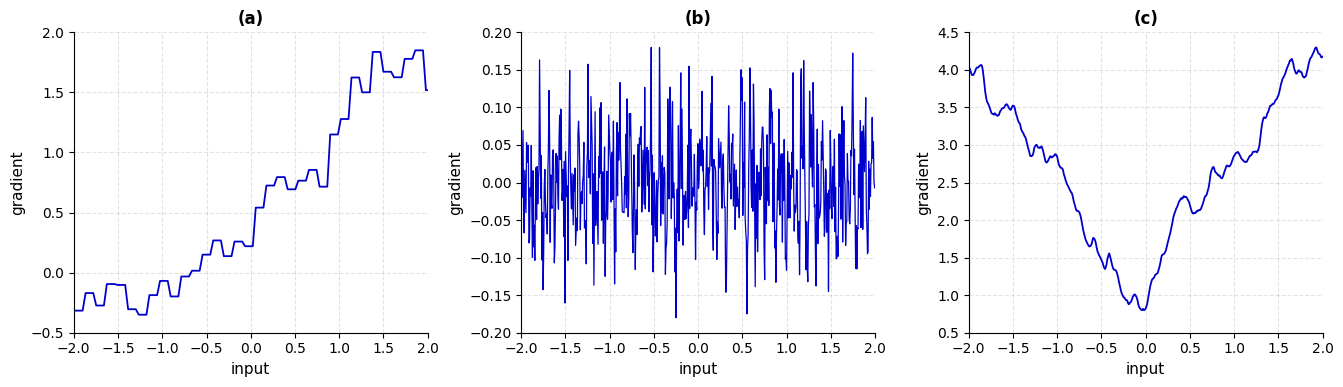

In [2]:
# 図 9.12: 層の深さと残差結合の有無による入力勾配の振る舞い
# (a) 2層フィードフォワード（滑らか）
# (b) 25層フィードフォワード（ホワイトノイズ / 勾配破砕）
# (c) 51層残差ネットワーク（ブラウン運動 / 空間相関の維持）
fig912 = generate_figure_9_12()
plt.show()


### 図 9.12の理論的考察と定量的特性

1. **Panel (a) - 浅いネットワーク (2層)**:
   隠れ層が1つの場合、活性化関数の境界は少なく、勾配 $\frac{\partial y}{\partial x}$ は広い入力区間にわたって区分的に滑らかです。勾配の方向が局所的に一貫しているため、標準的な学習率での勾配降下法が安定して進みます。

2. **Panel (b) - 深い標準ネットワーク (25層)**:
   25層のReLUが合成されると、空間は $O(2^{25})$ 個の超微小な線形ポリトープに分割されます。
   Balduzzi et al. (2017) は、勾配の自己相関関数 $C(\delta) = \mathbb{E}[\langle \nabla_x y(x), \nabla_x y(x + \delta) \rangle]$ が $\delta$ に対して極めて急峻に減衰し、$C(\delta) \to 0$ となることを証明しました。
   これが**勾配破砕問題（Shattered Gradients Problem）**であり、局所的にはランダムなコイントスと同等になるため、SGDは前進できなくなります。

3. **Panel (c) - 超深層残差ネットワーク (51層 ResNet)**:
   スキップ接続 $\mathbf{z}_\ell = \mathbf{z}_{\ell-1} + f(\mathbf{z}_{\ell-1})$ が各層に追加されると、勾配の逆伝播は恒等経路を通じて非線形層の減衰・増幅を受けずに直接足し合わされます。
   その結果、勾配の空間相関は Wiener過程（ブラウン運動）に漸近し、長距離にわたる秩序が回復します。


## 2. 残差ブロックの数学的定式化 (Mathematical Formulation)

### 基本残差写像と恒等接続 (式 9.32 - 9.37)
第 $\ell$ 層における隠れ状態ベクトルを $\mathbf{z}_{\ell-1}$、重みパラメータを $\mathbf{w}_\ell$ とするとき、通常のフィードフォワード層が直接的なマッピング $\mathbf{z}_\ell = f(\mathbf{z}_{\ell-1}, \mathbf{w}_\ell)$ を学習しようとするのに対し、**残差ブロック (Residual Block)** は差分（残差）写像を学習します：

$$\begin{aligned}
\mathbf{z}_\ell = \mathbf{z}_{\ell-1} + f(\mathbf{z}_{\ell-1}, \mathbf{w}_\ell) \quad \text{(式 9.32)}
\end{aligned}$$

より一般には、スキップ経路に関数 $g(\mathbf{z}_{\ell-1})$ を含めることができます：
$$\begin{aligned}
\mathbf{z}_\ell = g(\mathbf{z}_{\ell-1}) + f(\mathbf{z}_{\ell-1}, \mathbf{w}_\ell)
\end{aligned}$$
しかし、He et al. (2016b) の徹底的な実験と理論解析により、$g(\mathbf{z}) = \mathbf{z}$（厳密な恒等写像: Identity Mapping）とすることが最良の勾配伝播を保証することが示されています。

### 3段残差ネットワークの展開式 (式 9.35 - 9.37)
入力 $\mathbf{x}$ から出力 $\mathbf{y}$ に至る3ブロックの変換系列は以下の通りです：
$$\begin{aligned}
\mathbf{z}_1 &= \mathbf{x} + \mathbf{F}_1(\mathbf{x}) \quad \text{(式 9.35)} \\
\mathbf{z}_2 &= \mathbf{z}_1 + \mathbf{F}_2(\mathbf{z}_1) \quad \text{(式 9.36)} \\
\mathbf{y} &= \mathbf{z}_2 + \mathbf{F}_3(\mathbf{z}_2) \quad \text{(式 9.37)}
\end{aligned}$$

### チャネル次元変更時の射影行列 $\mathbf{W}$ (式 9.41)
ネットワークの途中で特徴マップのチャネル数や空間解像度が変化する場合、直接の加算 $\mathbf{z}_{\ell-1} + f(\mathbf{z}_{\ell-1})$ が行えないため、スキップ経路上に線形射影行列 $\mathbf{W}_\ell$（通常は $1\times 1$ 畳み込み）を適用します：
$$\begin{aligned}
\mathbf{z}_\ell = \mathbf{W}_\ell \mathbf{z}_{\ell-1} + f(\mathbf{z}_{\ell-1}, \mathbf{w}_\ell) \quad \text{(式 9.41)}
\end{aligned}$$


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/9/result/Figure_9_13.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_9_13.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/9/result/fig_9_13_residual_network_architecture.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_9_13_residual_network_architecture.png


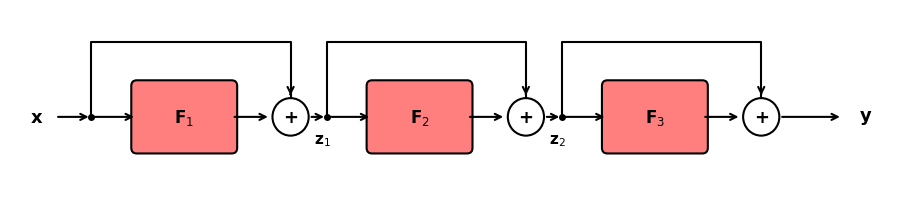

In [3]:
# 図 9.13: 3つの残差ブロックから構成される残差ネットワークのアーキテクチャ (式 9.35 - 9.37)
fig913 = generate_figure_9_13()
plt.show()


### 図 9.13の解説: 恒等ショートカットと加算ノード

図 9.13 に示すように、残差ネットワークの最大の特徴は**加算ノード（$\bigoplus$）**によるスキップ接続です：
1. **恒等経路（ショートカット）**:
   ブロック $\mathbf{F}_i$ を迂回する上部の経路は、信号と勾配を減衰なしに通過させます。
2. **残差分岐 $\mathbf{F}_i$**:
   通常は2層〜3層の畳み込み層（Convolution）または線形層（Linear）とReLU活性化関数で構成され、基底表現に対する微小な「補正量」を計算します。
3. **初期化時の利点**:
   重み初期化時に $\mathbf{F}_i$ の出力が小さく（あるいはゼロに）保たれていれば、ネットワーク全体は初期状態で単なる恒等写像 $\mathbf{y} \approx \mathbf{x}$ として振る舞うため、どれほど層が深くても信号が消散・発散しません。


## 3. 幾何学的最適化と損失曲面の平滑化 (Loss Landscape Smoothing)

超深層ネットワークの成否を決定づける幾何学的要因として、**損失超曲面（Loss Landscape）の平滑化**があります（Li et al., 2017）。

### フィルタ正規化（Filter Normalization）による可視化手法
数百万〜数千万次元のパラメータ空間 $\boldsymbol{\theta} \in \mathbb{R}^D$ の損失曲面 $L(\boldsymbol{\theta})$ を2次元平面上で忠実に評価するため、最適解 $\boldsymbol{\theta}^*$ からの2つのランダム直交方向 $\boldsymbol{\delta}, \boldsymbol{\eta} \in \mathbb{R}^D$ を用いて以下のように断面をサンプリングします：
$$
f(\alpha, \beta) = L(\boldsymbol{\theta}^* + \alpha \boldsymbol{\delta} + \beta \boldsymbol{\eta})
$$
ここで、重みテンソルのスケール不変性による見かけの歪みを防ぐため、各フィルタ（畳み込みカーネルや重みベクトル）のノルムに比例させて方向ベクトルを正規化します（Filter-wise Normalization）：
$$
\boldsymbol{\delta}_{i,j} \leftarrow \frac{\boldsymbol{\delta}_{i,j}}{\|\boldsymbol{\delta}_{i,j}\|} \|\boldsymbol{\theta}^*_{i,j}\|
$$

### スキップ結合の有無による決定的な違い
- **56層 フィードフォワード（スキップなし）**:
  高次元の非線形干渉により、損失曲面は無数の鋭利な局所解、鞍点、混沌とした尾根（Ridges）で埋め尽くされます。初期値が少しずれるだけで全く異なる不良局所解にトラップされます。
- **56層 ResNet（スキップあり）**:
  スキップ結合が凸状の基底ポテンシャルを提供するため、無秩序な谷が消滅し、ほぼ大域的に凸な美しい「すり鉢状（Convex-like Bowl）」のボウルが形成されます。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/9/result/Figure_9_14.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_9_14.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/9/result/fig_9_14_loss_landscapes_3d.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_9_14_loss_landscapes_3d.png


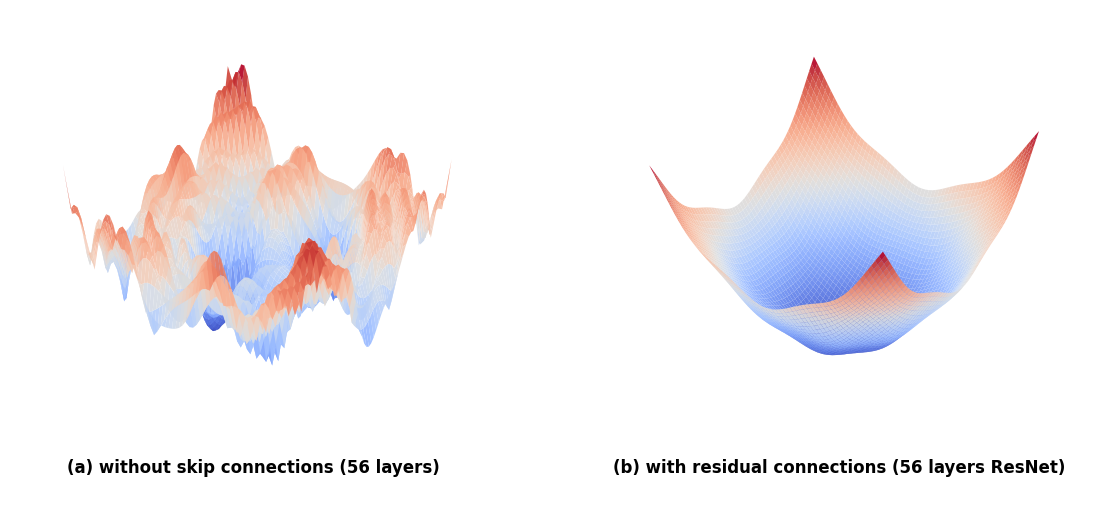

In [4]:
# 図 9.14: 損失曲面の3D可視化 (Li et al., 2017)
# (a) 56層フィードフォワード（スキップなし: 混沌・多峰）
# (b) 56層ResNet（スキップあり: 滑らかな単峰凸状ボウル）
fig914 = generate_figure_9_14()
plt.show()


### 図 9.14の解釈: なぜResNetは最適化しやすいのか

図 9.14 の3Dプロットから明らかなように：
- **Panel (a)（スキップ結合なし）**:
  中心付近に極めて急峻で予測不可能な断崖絶壁と無数の局所的窪みが存在します。大きな学習率では発散し、小さな学習率では平坦な鞍点や浅い局所解で身動きが取れなくなります。
- **Panel (b)（スキップ結合あり）**:
  損失曲面は大域的に滑らかで、中心の最適解に向かって均一な勾配傾斜が形成されています。これにより、単純な確率的勾配降下法（SGD）やAdamが極めて安定して大域的優良解へと収束できます。


## 4. アンサンブルとしての残差ネットワーク解釈 (Veit et al., 2016)

残差ネットワークのもう一つの驚くべき理論的解釈は、**「ResNetは指数関数的に多数の浅いネットワークのアンサンブルである」**という視点です（Veit et al., 2016 / 教科書第9.5節、演習 9.13）。

### 再帰的展開による $2^L$ 個のパス表現 (式 9.38 - 9.40)
式 (9.35) - (9.37) の3ブロックResNetの出力を代入・展開してみます：
$$\begin{aligned}
\mathbf{y} &= \mathbf{z}_2 + \mathbf{F}_3(\mathbf{z}_2) \\
&= [\mathbf{z}_1 + \mathbf{F}_2(\mathbf{z}_1)] + \mathbf{F}_3(\mathbf{z}_1 + \mathbf{F}_2(\mathbf{z}_1)) \\
&= [\mathbf{x} + \mathbf{F}_1(\mathbf{x}) + \mathbf{F}_2(\mathbf{x} + \mathbf{F}_1(\mathbf{x}))] + \mathbf{F}_3(\mathbf{x} + \mathbf{F}_1(\mathbf{x}) + \mathbf{F}_2(\mathbf{x} + \mathbf{F}_1(\mathbf{x}))) \quad \text{(式 9.38)}
\end{aligned}$$

一般に、$L$ 個の残差ブロックを持つネットワークは、各ブロックで「スキップする」か「ブロック $\mathbf{F}_i$ を通過する」かの2択の分岐を持つため、全体として **$2^L$ 個の異なる経路（Paths）の重ね合わせ**として表されます：
$$\begin{aligned}
\mathbf{z}_L = \sum_{S \subseteq \{1, \dots, L\}} F_S(\mathbf{x}) \quad \text{(式 9.40)}
\end{aligned}$$
ここで $S$ は通過するブロックの部分集合であり、$F_S$ はその部分集合に属するブロックを直列に適用する複合関数です。

### パス長の二項分布と病変実験（Lesion Studies）
- 長さ $k$ のパスの個数は二項係数 $\binom{L}{k}$ で与えられます。
- パス長の平均は $L/2$ であり、有効パス長の大部分は中程度の深さに集中しています。
- 通常のフィードフォワード網では、途中の1層を削除するとネットワーク全体の情報伝達が完全に破壊されます。
- 一方、ResNetでは推論時に任意の1つの残差ブロックを丸ごと削除（Lesion）しても、$2^L$ 個のパスのうち半分のパス（そのブロックを含まない $2^{L-1}$ 個のパス）が無傷で残るため、予測性能は滑らかにしか劣化しません。これはまさに**バギングやアンサンブルモデルと同一の性質**です。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/9/result/Figure_9_15.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_9_15.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/9/result/fig_9_15_residual_expanded_ensemble.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_9_15_residual_expanded_ensemble.png


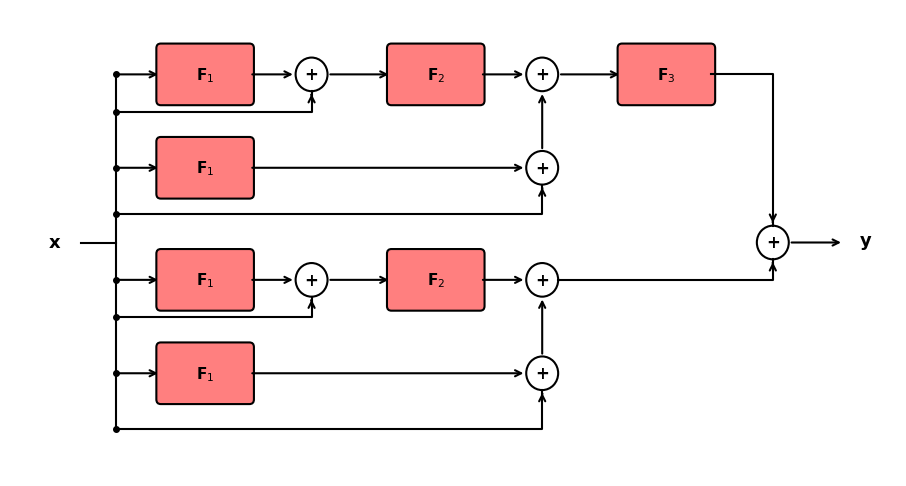

In [5]:
# 図 9.15: 式 (9.40) に対応する残差ネットワークの展開形式（パスアンサンブル）
fig915 = generate_figure_9_15()
plt.show()


### 図 9.15の解説: 展開形式に見る並列情報流

図 9.15 は、3ブロックの残差ネットワークを展開して得られる $2^3 = 8$ 個のパスの結合構造を示しています：
1. **最短パス（長さ 0）**:
   すべてのブロックをスキップし、入力 $\mathbf{x}$ がそのまま出力に直接加算される経路。
2. **単一ブロックパス（長さ 1）**:
   $\mathbf{F}_1$ のみ、$\mathbf{F}_2$ のみ、あるいは $\mathbf{F}_3$ のみを通る3通りの経路。
3. **2ブロックパス（長さ 2）**:
   $(\mathbf{F}_1, \mathbf{F}_2)$、$(\mathbf{F}_1, \mathbf{F}_3)$、$(\mathbf{F}_2, \mathbf{F}_3)$ を通る3通りの経路。
4. **最長パス（長さ 3）**:
   $\mathbf{F}_1 \to \mathbf{F}_2 \to \mathbf{F}_3$ をすべて通過する唯一の超深層経路。

この視点から、残差ネットワークの卓越した性能は、**超深層モデルの表現力を持ちながら、勾配の大部分は勾配破砕や勾配消失を受けない浅い〜中程度の長さのパスを通じて運ばれる**というアンサンブル的シナジーによるものであることが理解できます。


## 5. アーキテクチャの変種: 事後活性化 vs 事前活性化 (He et al., 2016b)

残差ブロック内の演算順序には、大きく分けて2つの設計思想が存在します（図 9.16）：

1. **事後活性化 (Post-activation: He et al., 2016a)**:
   $$\mathbf{z}_\ell = h(\mathbf{z}_{\ell-1} + f(\mathbf{z}_{\ell-1}, \mathbf{w}_\ell))$$
   加算の後に非線形活性化関数 $h$（ReLU）を適用します。
   - **欠点**: 恒等スキップ経路上にReLUが挟まるため、負の値がゼロにクリップされ、純粋な恒等写像 $\mathbf{z}_L = \mathbf{z}_0 + \sum f_i$ が崩れます。これにより100層を超える超深層において勾配伝播が阻害されます。

2. **事前活性化 (Pre-activation: He et al., 2016b)**:
   $$\mathbf{z}_\ell = \mathbf{z}_{\ell-1} + f(h(\mathbf{z}_{\ell-1}), \mathbf{w}_\ell)$$
   活性化（ReLUやBatch Normalization）を重み層の直前（残差分岐の内側）に配置します。
   - **利点**: スキップ接続上に一切の非線形関数が存在せず、完全な**勾配ハイウェイ（Gradient Highway）**が実現します。1000層を超える極限の深さでも安定した学習が可能になります。

> **[教科書の誤植に関する注記]**:
> 原著テキスト Figure 9.16 (b) において、右側のブロック2の2番目の箱に「ReLU」（オレンジ色背景）と印刷されていますが、これは誤植（Typo）であり、正しくは「Linear」（線形重み層）です。本実装および図版では正しく修正したアーキテクチャを図示しています。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/9/result/Figure_9_16.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_9_16.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/9/result/fig_9_16_residual_block_variants.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_9_16_residual_block_variants.png


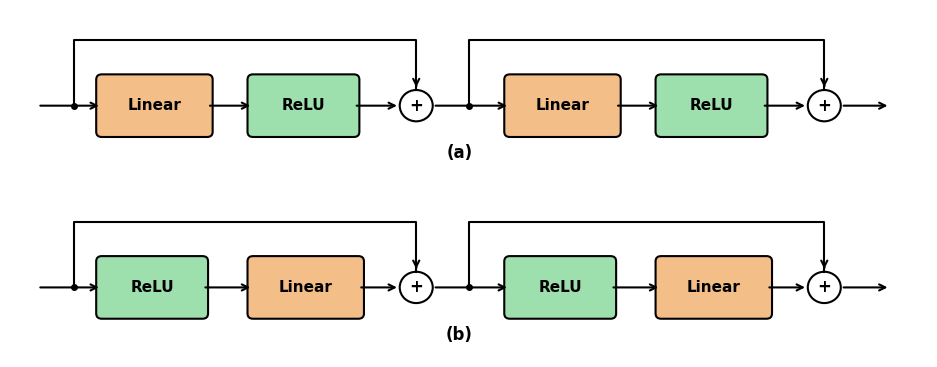

In [6]:
# 図 9.16: 残差結合の2つの構成方式
# (a) 事後活性化 (Post-activation: Linear -> ReLU -> Add)
# (b) 事前活性化 (Pre-activation: ReLU -> Linear -> Add)
fig916 = generate_figure_9_16()
plt.show()


### 図 9.16の解説と設計の比較

- **Panel (a) 事後活性化 (Post-activation)**:
  ResNetの初期論文（He et al., 2016a）で採用された標準設計です。
  各ブロックの最後で加算した直後にReLUを通すため、出力 $\mathbf{z}_\ell$ は常に非負となります。しかし、この非負制約はスキップ経路を流れる信号のダイナミックレンジを制約し、層が深くなるにつれて勾配の流通を妨げます。
- **Panel (b) 事前活性化 (Pre-activation)**:
  He et al. (2016b) で提案された改良設計です。
  ReLUを重み層の手前に移すことで、加算ノード間のスキップ接続は一切の演算を含まない完全な恒等リンクとなります。
  任意の2層 $\ell_1 < \ell_2$ 間で信号は直接 $\mathbf{z}_{\ell_2} = \mathbf{z}_{\ell_1} + \sum_{i=\ell_1+1}^{\ell_2} f_i$ として伝達され、逆伝播における誤差勾配も $\frac{\partial L}{\partial \mathbf{z}_{\ell_1}} = \frac{\partial L}{\partial \mathbf{z}_{\ell_2}} (\mathbf{I} + \dots)$ となり、減衰のない恒等勾配伝播が数学的に保証されます。


## 6. 数値検証と共通モジュールの動作確認

本節で開発した共通モジュール `common/residual_connections.py` に含まれる以下の主要コンポーネントを数値的に検証します：
1. `DeepFeedforwardNetwork` vs `DeepResidualNetwork` のヤコビアン計算
2. `ResidualBlock` の事後活性化（Post-activation）、事前活性化（Pre-activation）、および次元変更時射影（Projection shortcut: 式 9.41）


In [7]:
# 1. 勾配の連続性・統計的特性の検証
x_test = np.linspace(-2.0, 2.0, 100)

ff_net = DeepFeedforwardNetwork(d_in=1, d_hidden=24, d_out=1, n_layers=25, seed=42)
res_net = DeepResidualNetwork(d_in=1, d_hidden=24, d_out=1, n_blocks=25, seed=42)

grad_ff = ff_net.jacobian(x_test)
grad_res = res_net.jacobian(x_test)

# 勾配の自己相関・符号反転頻度の計算
flips_ff = np.sum(np.diff(np.sign(grad_ff)) != 0)
flips_res = np.sum(np.diff(np.sign(grad_res)) != 0)

print(f"25-layer Feedforward Gradient Sign Flips: {flips_ff} / {len(x_test)-1}")
print(f"51-layer ResNet Gradient Sign Flips:     {flips_res} / {len(x_test)-1}")

# 2. ResidualBlock の動作検証
block_post = ResidualBlock(d_in=8, d_out=8, variant="post_activation")
block_pre = ResidualBlock(d_in=8, d_out=8, variant="pre_activation")
block_proj = ResidualBlock(d_in=8, d_out=16, variant="post_activation")  # 次元拡大

x_sample = np.random.randn(4, 8)
out_post = block_post.forward(x_sample)
out_pre = block_pre.forward(x_sample)
out_proj = block_proj.forward(x_sample)

print("\nResidualBlock Forward Outputs:")
print(f"Post-activation output shape: {out_post.shape} (all >= 0: {np.all(out_post >= 0)})")
print(f"Pre-activation output shape:  {out_pre.shape}")
print(f"Projection shortcut shape:   {out_proj.shape} (d_in=8 -> d_out=16)")

assert out_post.shape == (4, 8)
assert out_pre.shape == (4, 8)
assert out_proj.shape == (4, 16)
assert flips_ff > flips_res, "Feedforward network should shatter gradients with significantly more sign flips!"
print("\nAll numerical checks successfully passed!")


25-layer Feedforward Gradient Sign Flips: 33 / 99
51-layer ResNet Gradient Sign Flips:     1 / 99

ResidualBlock Forward Outputs:
Post-activation output shape: (4, 8) (all >= 0: False)
Pre-activation output shape:  (4, 8)
Projection shortcut shape:   (4, 16) (d_in=8 -> d_out=16)

All numerical checks successfully passed!


## 7. まとめと第9.6節（モデル平均とドロップアウト）への展望

### 本節の要点まとめ
1. **退化問題と勾配破砕 (Shattered Gradients)**:
   超深層フィードフォワード網では、勾配がホワイトノイズ化して空間相関が急速に失われる。残差接続は勾配をブラウン運動に変換し、長距離相関を回復させる。
2. **残差ブロックの定式化 (式 9.32 - 9.41)**:
   残差写像 $f(\mathbf{z})$ を学習することで、初期状態での恒等写像が保証され、チャネル変化時には射影行列 $\mathbf{W}$ を用いて柔軟に対応する。
3. **損失曲面の平滑化 (Li et al., 2017)**:
   スキップ接続は高次元損失超曲面の無数の極小解や鞍点を一掃し、滑らかな凸状ボウルへと変換する。
4. **パスアンサンブル解釈 (Veit et al., 2016)**:
   ResNetは $2^L$ 個の浅いネットワークのアンサンブルであり、任意のブロックの欠落に対しても頑健な耐性を持つ。
5. **事前活性化 (Pre-activation)**:
   活性化をブロック内部に配置することで、スキップ経路上に完全な恒等情報ハイウェイを開通させ、1000層超の安定学習を可能にする。

### 次節への展望: 9.6 モデル平均 (Model Averaging)
次節 **9.6 モデル平均 (Model Averaging)** では、独立に訓練された複数のモデルの予測を結合するアンサンブル法の統計的基礎（バギング、ブースティング等）と、深層学習における最も重要かつ効率的な確率的正則化手法である **9.6.1 ドロップアウト (Dropout)** の理論的・実践的メカニズムを解明します。
